# 판다스(pandas)
- 시리즈
- 데이터프레임

In [1]:
import numpy as np
import pandas as pd
data1 = np.arange(1, 6)
data1

# 1차원적 
data2 = pd.Series(data1)
print(data2, type(data2), data2.index, data2.values, data2.dtype)

0    1
1    2
2    3
3    4
4    5
dtype: int64 <class 'pandas.core.series.Series'> RangeIndex(start=0, stop=5, step=1) [1 2 3 4 5] int64


In [2]:
# 판다스 시리즈의 데이터 타입
data3 = pd.Series([11, 22, 33, 44, 55], dtype='float')
print(data3)

0    11.0
1    22.0
2    33.0
3    44.0
4    55.0
dtype: float64


In [3]:
data4 = pd.Series([44, 55, 66, 77, 88], index=["aa", "bb", "cc", "dd", "ee"])
print(data4)

aa    44
bb    55
cc    66
dd    77
ee    88
dtype: int64


In [4]:
# 판다스 시리즈 딕셔너리데이터

population_dict = {
    "korea": 5182,
    "japan": 12622,
    "china": 141178,
    "usa": 32976
}
# population_dict.keys()
# population_dict.values()
# population_dict.items()

country = pd.Series(population_dict)
print(country, country.index, country.values)
print(country.ndim, country.shape, country.size)
# 시리즈 원소에 접근방법
print(country.loc["usa"])
print(country.iloc[3])

korea      5182
japan     12622
china    141178
usa       32976
dtype: int64 Index(['korea', 'japan', 'china', 'usa'], dtype='object') [  5182  12622 141178  32976]
1 (4,) 4
32976
32976


In [5]:
population_dict = {
    "korea": 5182,
    "japan": 12622,
    "china": 141178,
    "usa": 32976
}
GDP_dict = {
    "korea": 169320000,
    "japan": 516700000,
    "china": 140925000,
    "usa": 2041280000
}

pup = pd.Series(population_dict)
GDP = pd.Series(GDP_dict)
country = pd.DataFrame({"population":pup, "GDP":GDP})
country.index.name = "Country"
country.columns.name = "Info"
print(country.index, country.columns)
print(country.values, country.shape, country.size, country.ndim)

Index(['korea', 'japan', 'china', 'usa'], dtype='object', name='Country') Index(['population', 'GDP'], dtype='object', name='Info')
[[      5182  169320000]
 [     12622  516700000]
 [    141178  140925000]
 [     32976 2041280000]] (4, 2) 8 2


In [6]:
country.loc["korea"], country.loc["usa"]
country.iloc[2], country.iloc[1]

(Info
 population       141178
 GDP           140925000
 Name: china, dtype: int64,
 Info
 population        12622
 GDP           516700000
 Name: japan, dtype: int64)

In [7]:
country.loc["korea":"japan"]

Info,population,GDP
Country,,
korea,5182,169320000
japan,12622,516700000


In [8]:
country.iloc[0:2] # <= x <

Info,population,GDP
Country,,
korea,5182,169320000
japan,12622,516700000


In [9]:
# 컬럼추가
# country['what?'] = [11, 22, 33, 44]
per = country['GDP']/country['population']
country["GDP_per"] = per

In [10]:
country

Info,population,GDP,GDP_per
Country,,,
korea,5182,169320000,32674.642995
japan,12622,516700000,40936.460149
china,141178,140925000,998.207936
usa,32976,2041280000,61901.989326


In [12]:
# 컬럼삭제
country = country.drop("what?", axis=1)

KeyError: "['what?'] not found in axis"

In [13]:
country

Info,population,GDP,GDP_per
Country,,,
korea,5182,169320000,32674.642995
japan,12622,516700000,40936.460149
china,141178,140925000,998.207936
usa,32976,2041280000,61901.989326


In [14]:
# 과일별 가격(원)
price = {
    "Apple": 1200,
    "Banana": 800,
    "Orange": 1500,
    "Mango": 2500
}

# 과일별 갯수
quan = {
    "Apple": 10, 
    "Banana": 5,
    "Orange": 7,
    "Mango": 20
}

# 위 내용을 이용하여 데이터 프레임으로 만들고 마지막컬럼은 행의 토탈가격을 붙여라.

# # 데이터프레임 생성
# fruits = pd.Series(price)
# piece = pd.Series(quan)
# fruit = pd.DataFrame({"price": fruits, "piece":piece})
# fruit.index.name = "Fruit"
# fruit.columns.name = "Info"

# total = fruit["price"] * fruit["piece"]
# fruit["Total"] = total
# fruit.loc["kiwi"] = [800, 11, None]
# fruit

fruit = pd.DataFrame({"price":price, "quan": quan})
fruit["won"] = fruit["price"] * fruit["quan"]

# 행추가 방법1
fruit.loc['kiwi'] = [800, 11, np.nan]
fruit.loc["kiwi", "won"] = fruit.loc['kiwi', 'price'] * fruit.loc['kiwi', 'quan']

# 행추가 방법2
melon = pd.Series(data=[4500, 6, 4500*6], index=['price', 'quan', 'won'])
fruit.loc['melon'] = melon
fruit

# 행추가 해서 결측값 확인하기
fruit.loc['lemon'] = [200, np.nan, np.nan]
fruit.isnull()  # .sum() 개수를 파악할 때

# NaN 값이 있는 행을 찾는 방법 1
fruit.drop(fruit[fruit['won'].isnull()].index)

# NaN 값이 있는 행을 찾는 방법 2
# fruit[ax.any(axis=1)].index

# 삭제 fruit.drop(위에서 찾은 인덱스를 넣어주면 됨)

,price,quan,won
Apple,1200.0,10.0,12000.0
Banana,800.0,5.0,4000.0
Orange,1500.0,7.0,10500.0
Mango,2500.0,20.0,50000.0
kiwi,800.0,11.0,8800.0
melon,4500.0,6.0,27000.0


In [15]:
country

Info,population,GDP,GDP_per
Country,,,
korea,5182,169320000,32674.642995
japan,12622,516700000,40936.460149
china,141178,140925000,998.207936
usa,32976,2041280000,61901.989326


In [16]:
country[country['population'] > 30000]

Info,population,GDP,GDP_per
Country,,,
china,141178,140925000,998.207936
usa,32976,2041280000,61901.989326


In [17]:
f = (country['population'] > 6000) & (country['population'] < 100000)

# 원하는 컬럼 선택 1
country[f][['GDP_per', 'population']]

# 원하는 컬럼 선택 2

country[f].loc['japan':'japan', 'population':'GDP']

Info,population,GDP
Country,,
japan,12622,516700000


# 실습 1
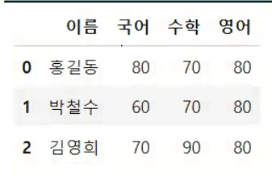

In [18]:
data = {
    '이름' : ['홍길동', '박철수', '김영희'],
    '국어' : [80, 60, 70],
    '수학' : [70, 70, 90],
    '영어' : [80, 80, 80]
}
df = pd.DataFrame(data)
df

,이름,국어,수학,영어
0,홍길동,80,70,80
1,박철수,60,70,80
2,김영희,70,90,80


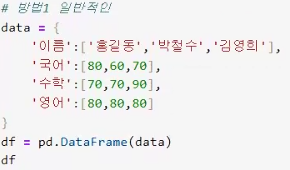

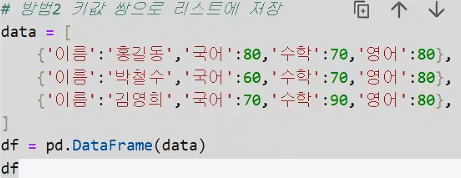

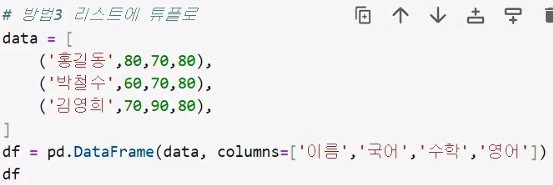

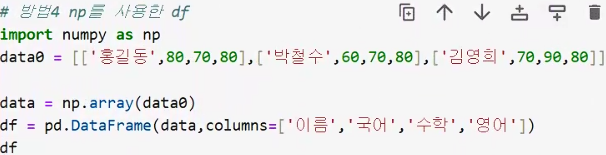

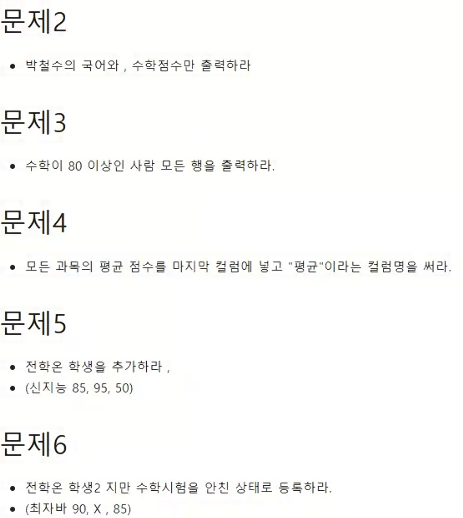

In [19]:
#2
df.loc[df["이름"]=="박철수", ["이름", "국어", "수학"]]

,이름,국어,수학
1,박철수,60,70


In [20]:
#3
df[df["수학"] >= 80]

,이름,국어,수학,영어
2,김영희,70,90,80


In [21]:
df["평균"] = df[["국어","수학","영어"]].mean(axis=1)
df

,이름,국어,수학,영어,평균
0,홍길동,80,70,80,76.666667
1,박철수,60,70,80,70.000000
2,김영희,70,90,80,80.000000


In [22]:
df.loc[len(df)] = {"이름":"신지능", "국어":85, "수학":95,"영어":50}
df

,이름,국어,수학,영어,평균
0,홍길동,80,70,80,76.666667
1,박철수,60,70,80,70.000000
2,김영희,70,90,80,80.000000
3,신지능,85,95,50,NaN


In [23]:
df.loc[len(df)] = {"이름":"최자바", "국어":90, "수학":"X", "영어":85}
df

,이름,국어,수학,영어,평균
0,홍길동,80,70,80,76.666667
1,박철수,60,70,80,70.000000
2,김영희,70,90,80,80.000000
3,신지능,85,95,50,NaN
4,최자바,90,X,85,NaN


# 판다스(pandas) 심화

## 데이터프레임 정렬

In [25]:
import numpy as np
import pandas as pd
print("DdataFrame: ")
data = {
    'col1': [2, 1, 9, 8, 7, 4],
    'col2': ['A', 'A', 'B', np.nan, 'D', 'C'],
    'col3': [0, 1, 9, 4, 2, 3],
}
index = [1, 3, 2, 5, 0, 4]
df = pd.DataFrame(data, index=index)
df

DdataFrame: 


,col1,col2,col3
1,2,A,0
3,1,A,1
2,9,B,9
5,8,NaN,4
0,7,D,2
4,4,C,3


In [29]:
df = df.sort_index(axis=0)  # 행을 축으로 정렬
df

,col1,col2,col3
0,7,D,2
1,2,A,0
2,9,B,9
3,1,A,1
4,4,C,3
5,8,NaN,4


In [30]:
df.sort_index(axis=1, ascending=False)  # 열을 축으로 정렬, 내림차순

,col3,col2,col1
0,2,D,7
1,0,A,2
2,9,B,9
3,1,A,1
4,3,C,4
5,4,NaN,8


In [37]:
df.sort_values('col1', ascending=False)  # value를 기준으로 정렬

,col1,col2,col3
2,9,B,9
5,8,NaN,4
0,7,D,2
4,4,C,3
1,2,A,0
3,1,A,1


In [38]:
df.sort_values(['col2', 'col1'], ascending=[True, False])  # value를 기준으로 이중 정렬

,col1,col2,col3
1,2,A,0
3,1,A,1
2,9,B,9
4,4,C,3
0,7,D,2
5,8,NaN,4


## 데이터 분석용 함수

In [39]:
import numpy as np
import pandas as pd
data = {
    'korean': [50, 60, 70, 30],
    'math': [30, np.nan, 40, 20],
}
index = ['홍길순', '수퍼걸', '쉬헐크', '배트걸']
df = pd.DataFrame(data, index=index)
print(df.index)
print(df.columns)
df

Index(['홍길순', '수퍼걸', '쉬헐크', '배트걸'], dtype='object')
Index(['korean', 'math'], dtype='object')


,korean,math
홍길순,50,30.0
수퍼걸,60,NaN
쉬헐크,70,40.0
배트걸,30,20.0


In [40]:
# count() 함수
print(df.count())
print(df.count(axis=1))

korean    4
math      3
dtype: int64
홍길순    2
수퍼걸    1
쉬헐크    2
배트걸    2
dtype: int64


In [43]:
# max() 함수
print(df.max(axis=0))
print(df.max(axis=1))

korean    70.0
math      40.0
dtype: float64
홍길순    50.0
수퍼걸    60.0
쉬헐크    70.0
배트걸    30.0
dtype: float64


In [44]:
# min() 함수
print(df.min(axis=0))
print(df.min(axis=1))

korean    30.0
math      20.0
dtype: float64
홍길순    30.0
수퍼걸    60.0
쉬헐크    40.0
배트걸    20.0
dtype: float64


In [46]:
# sum() 함수
print(df.sum(axis=0))
print(df.sum(axis=1))

korean    210.0
math       90.0
dtype: float64
홍길순     80.0
수퍼걸     60.0
쉬헐크    110.0
배트걸     50.0
dtype: float64


In [50]:
# mean() 함수
print(df.mean(axis=0))
print(df.mean(axis=1))
print(df.mean(axis=1, skipna=False))
data1 = df.mean(axis=1, skipna=False)
data1[~data1.isnull()]

korean    52.5
math      30.0
dtype: float64
홍길순    40.0
수퍼걸    60.0
쉬헐크    55.0
배트걸    25.0
dtype: float64
홍길순    40.0
수퍼걸     NaN
쉬헐크    55.0
배트걸    25.0
dtype: float64


홍길순    40.0
쉬헐크    55.0
배트걸    25.0
dtype: float64

In [52]:
# df['math'].mean()
df['math'] = df['math'].fillna(df['math'].mean())
df

,korean,math
홍길순,50,30.0
수퍼걸,60,30.0
쉬헐크,70,40.0
배트걸,30,20.0


## 그룹으로 묶기 (groupby)

In [60]:
import numpy as np
import pandas as pd
df = pd.DataFrame({
    'key' : ['A', 'A', 'A', 'A', 'B', 'C'],
    'data1': [1, 2, 3, 1, 2, 3],
    'data2': [4, 4, 6, 0, 6, 1], 
})
print("DataFrame: ")
df

DataFrame: 


,key,data1,data2
0,A,1,4
1,A,2,4
2,A,3,6
3,A,1,0
4,B,2,6
5,C,3,1


In [61]:
df.groupby('key').sum()

,data1,data2
key,,
A,7,14
B,2,6
C,3,1


In [62]:
df.groupby(['key', 'data1']).sum().reset_index()

,key,data1,data2
0,A,1,4
1,A,2,4
2,A,3,6
3,B,2,6
4,C,3,1


In [63]:
df.groupby('key').mean()

,data1,data2
key,,
A,1.75,3.5
B,2.00,6.0
C,3.00,1.0


In [65]:
def filter_mean(x):
    return x['data2'].mean() > 3
df.groupby('key').filter(filter_mean)

,key,data1,data2
0,A,1,4
1,A,2,4
2,A,3,6
3,A,1,0
4,B,2,6
